In [159]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter

import yfinance as yf


In [160]:
# ============================================================
# 0 — Setup and Sector Filter
# ============================================================

# Load the dataset from the CSV file into a pandas DataFrame.
# Keep active operating companies only removing inactive securities, ETFs, and funds, 
# and filtered to only sector "Financial Services". 
# Absolute values are converted to billions and percentages.

df_raw = pd.read_csv("data/symbol_info_3-25.csv")

df = df_raw.copy()

df = df[
    (df["is_etf"] == 0) &
    (df["is_fund"] == 0) &
    (df["is_actively_trading"] == 1) &
    (df["market_cap"] > 0) &
    (df["total_revenue"] > 0) &
    (df["sector"] == "Financial Services")
].copy()

df["market_cap_b"] = df["market_cap"] / 1e9
df["enterprise_value_b"] = df["enterprise_value"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["net_income_b"] = df["net_income"] / 1e9
df["free_cashflow_b"] = df["free_cashflow"] / 1e9

df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100
df["dividend_yield_pct"] = df["dividend_yield"]

df = df.replace([np.inf, -np.inf], np.nan)

print("Cleaned investment:", df.shape) 
df[["symbol", "company_name", "sector", "market_cap_b", "revenue_b", "profit_margin_pct", "beta"]]





Cleaned investment: (150, 49)


,symbol,company_name,sector,market_cap_b,revenue_b,profit_margin_pct,beta
7,BRK-A,Berkshire Hathaway Inc.,Financial Services,1140.533625,371.433013,23.959999,0.858
8,BRK-B,Berkshire Hathaway Inc. New,Financial Services,1140.529824,371.433013,23.959999,0.858
14,JPM,JP Morgan Chase & Co.,Financial Services,675.624124,166.774997,35.060000,1.090
15,V,Visa Inc.,Financial Services,654.899479,36.801999,54.269004,0.949
17,MA,Mastercard Incorporated,Financial Services,489.022292,28.167000,45.706001,1.102
...,...,...,...,...,...,...,...
968,SNV,Synovus Financial Corp.,Financial Services,6.687569,1.852496,26.043999,1.391
975,BOKF,BOK Financial Corporation,Financial Services,6.590900,2.032399,25.760999,1.195
976,STEP,StepStone Group Inc.,Financial Services,6.583022,1.153911,-11.286000,1.323
986,VOYA,"Voya Financial, Inc.",Financial Services,6.531133,8.050000,8.286000,1.023


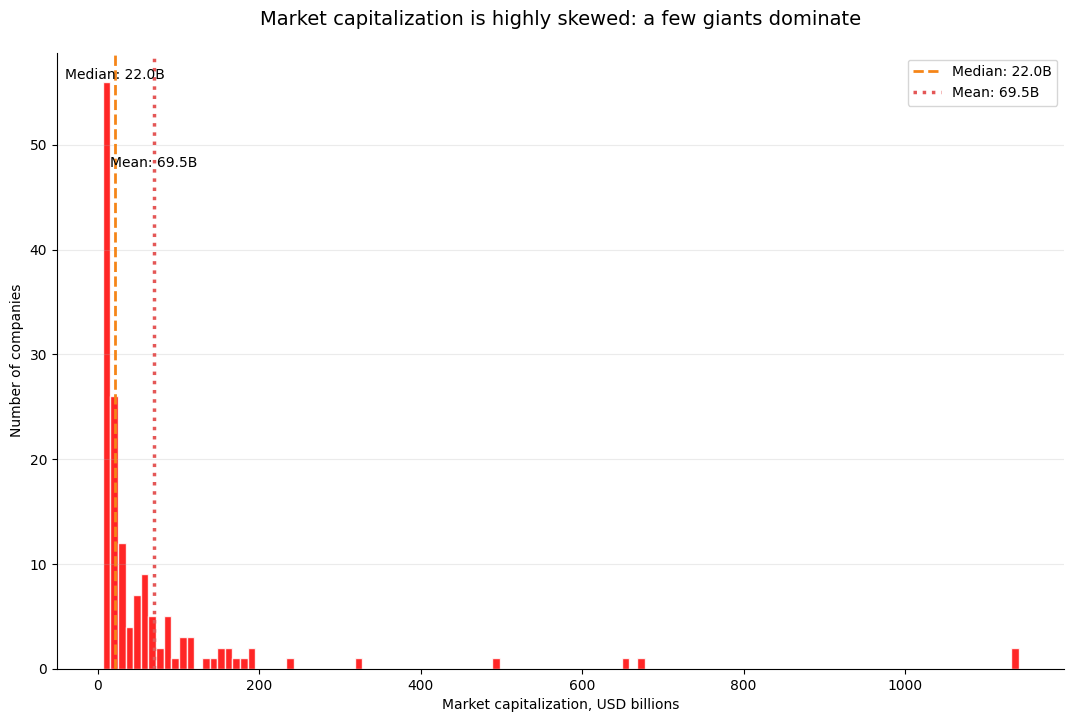

In [ ]:
# ============================================================
# 1 — Market Capitalization Distribution
# ============================================================

# In this block we generate a histogram to display the distribution of market capitalizations. 
# By contrasting the mean against the median, the histogram shows that the sector is heavily skewed
# demonstrating that a few "mega-cap" giants dominate the market while the normal company is  smaller.

market_cap = df["market_cap_b"].dropna()


fig, ax = plt.subplots(figsize=(13, 8))

# create histogram

n, bins, patches = ax.hist(
    market_cap, 
    bins=120, 
    color="red", 
    edgecolor="white", 
    alpha=0.85
)

# calculate mean and median and the max of the graph
median_value = market_cap.median()
mean_value = market_cap.mean()
top = n.max() 

# set vertical lines
ax.axvline(median_value, color="#F58518", linestyle="--", linewidth=2, label=f"Median: {median_value:,.1f}B")
ax.axvline(mean_value, color="#E45756", linestyle=":", linewidth=2.5, label=f"Mean: {mean_value:,.1f}B")

# put the text 
ax.text(median_value, top, f'Median: {median_value:.1f}B', 
        color="black", fontweight='light', ha='center', va='bottom')

ax.text(mean_value, top * 0.85, f'Mean: {mean_value:.1f}B', 
        color="black", fontweight='light', ha='center', va='bottom')

ax.set_title("Market capitalization is highly skewed: a few giants dominate", fontsize=14, pad=20)
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Number of companies")

ax.grid(axis="y", alpha=0.25)
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

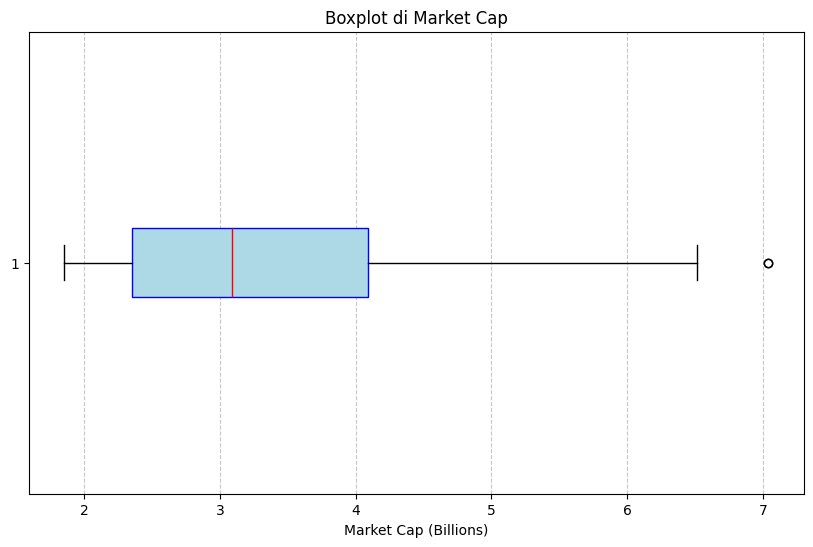

In [162]:
# ============================================================
# 2 — Outlier Detection
# ============================================================

# In this block we do a logarithmic transformation (np.log) to the mark_cap data this because financial data are highly skewed and so a boxplot without a log transformation
# would incorrectly flag almost all large companies as outliers. 
# in this way by logging the data first, the scale is normalized, and we can identify the true statistical outliers within the sector.
# Thid boxplot confirms what we observed in the previous plot, 
# many of the companies have more or less the same market cap concentrated between the 2B and 4B, and only few are bigger than the others 

df["market_cap_b"] = np.log(df["market_cap_b"])

plt.figure(figsize=(10, 6))

# create the boxplot
plt.boxplot(df['market_cap_b'], vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'))

# add label and creatre the grid
plt.title('Boxplot di Market Cap')
plt.xlabel('Market Cap (Billions)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

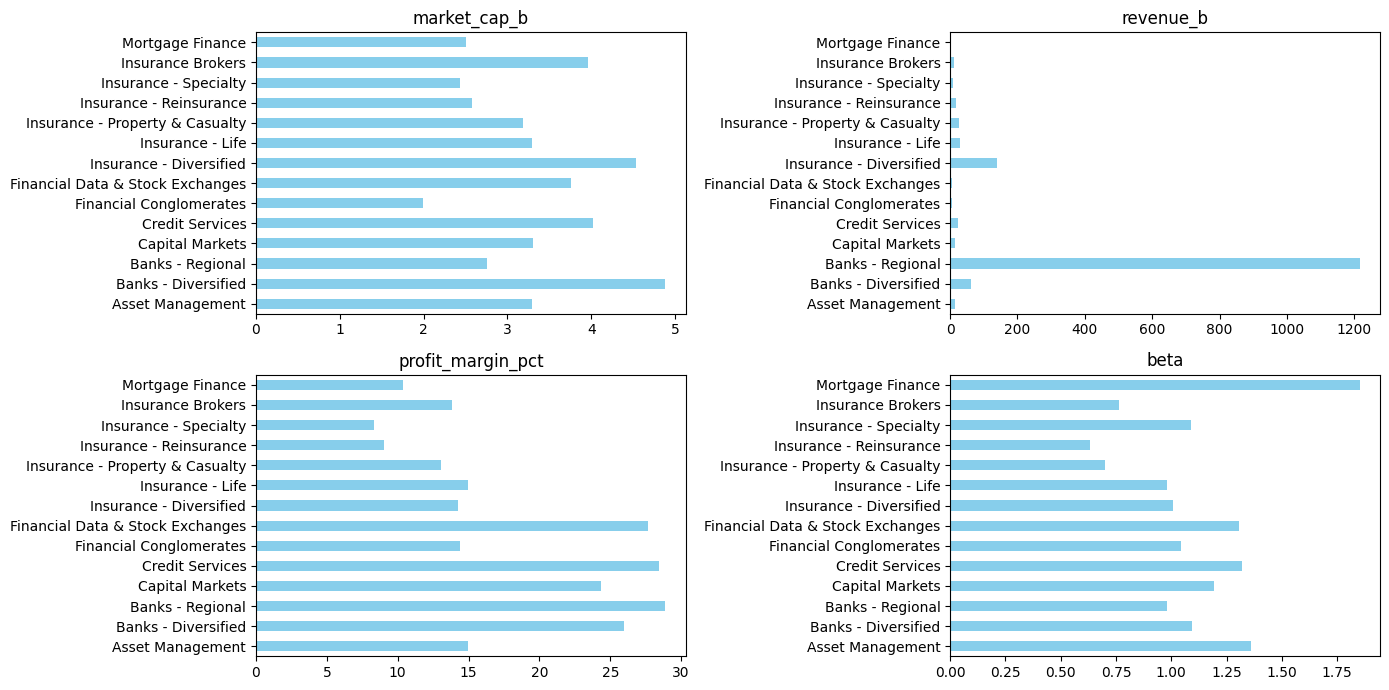

In [163]:
# ============================================================
# 3 — Industry Comparison: Four Metrics
# ============================================================

# In this block we group the companies by industry and calculate the average for four financial metrics: 
# Market Cap, Revenue, Profit Margin, and Beta. 
# Visualize the averages in a 2x2 grid of horizontal bar charts comparing the macroeconomic profiles
# revealing which industries offer the best balance of absolute scale, operational efficiency, and systemic market risk.


# define  the four metrics we want to analyze and compare.
metrics = ['market_cap_b', 'revenue_b', 'profit_margin_pct', 'beta']
df_grouped = df.groupby('industry')[metrics].mean()

# create the grid
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# create the horizontal bar chart and set the title with a for loop
for ax, metric in zip(axes.flatten(), metrics):
    df_grouped[metric].plot(kind='barh', ax=ax, title=metric, color='skyblue')
    ax.set_ylabel("") 

plt.tight_layout()
plt.show()

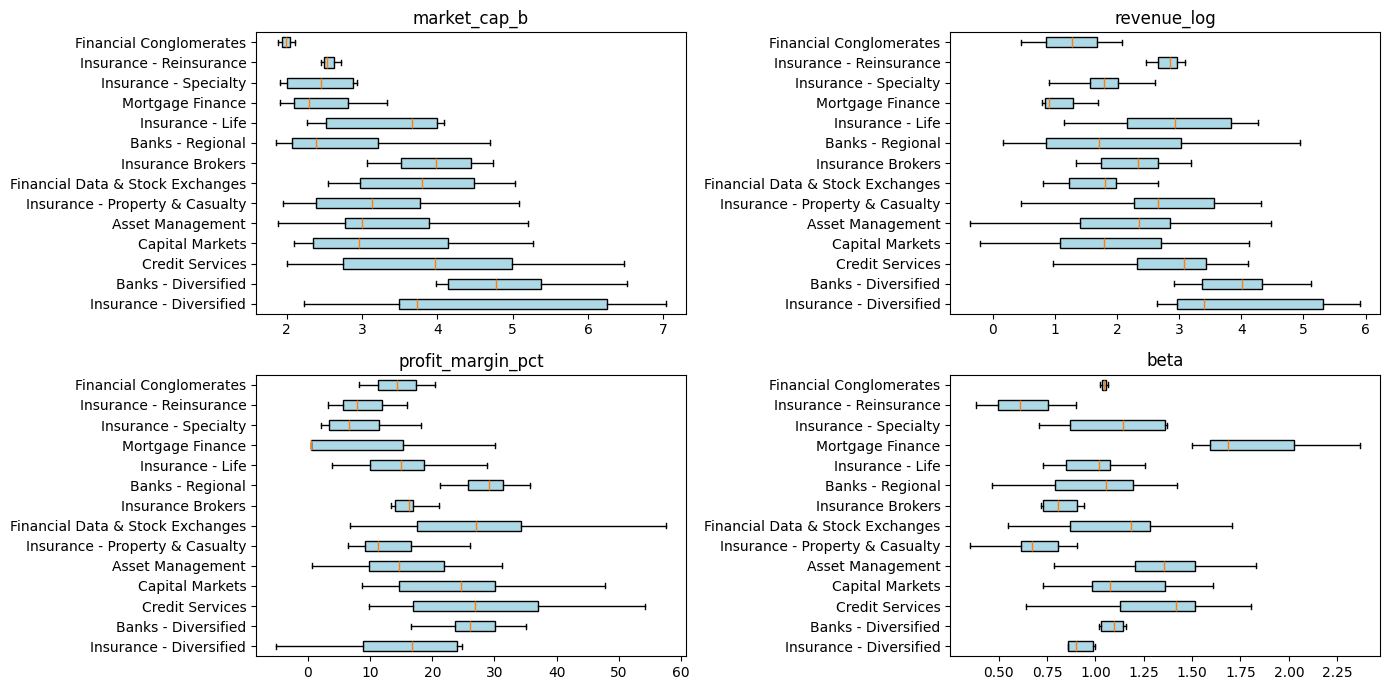

In [164]:
# ============================================================
# 4 — Industry Dispersion
# ============================================================

# In this block, instead of calculating the mean, we analyze the internal variance within each industry on different metrics. 
# This gives us the opportunity to study how much the companies of a specific industry are different based on some criteria.
# To do this, we create a 2x2 grid of horizontal boxplots and normalize the revenue to prevent distorsion.


# do a logarithmic transformation (np.log) to the revenue, as we did for the market cap for the skewness of data, to normalize its scale 
df["revenue_log"] = np.log(df["revenue_b"]) 

# choose the metrics
metrics = ['market_cap_b', 'revenue_log', 'profit_margin_pct', 'beta']

# creating the list of all unique sectors to group them 
industries = df['industry'].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for ax, metric in zip(axes.flatten(), metrics):
    data_to_plot = [df[df['industry'] == ind][metric].dropna() for ind in industries]
    
    ax.boxplot(data_to_plot, vert=False, patch_artist=True,
               showfliers=False, 
               boxprops=dict(facecolor='lightblue'))
    
    ax.set_title(metric)
    ax.set_yticks(range(1, len(industries) + 1))
    ax.set_yticklabels(industries)
    

plt.tight_layout()
plt.show()

### Key Insights from the Data

Looking at the charts, it's clear that most companies are spread out across all metrics, but a few specific points stand out:

* **Financial Conglomerates**: These show very low variance, meaning the companies in this group are extremely similar to each other and very consistent in their performance.
* **Insurance - Diversified**: On the flip side, this industry shows much higher variance than the others, indicating a huge gap between the top performers and the rest of the pack.

In [165]:
# ============================================================
# 5 — Focus Industry Selection
# ============================================================


df_cleaned = df[
    (df["industry"] == "Banks - Diversified") | 
    (df["industry"] == "Asset Management") |
    (df["industry"] == "Financial Data & Stock Exchanges") | 
    (df["industry"] == "Insurance - Diversified")
].copy()

print(df_cleaned["industry"].value_counts())

industry
Asset Management                    22
Financial Data & Stock Exchanges    11
Banks - Diversified                 10
Insurance - Diversified              6
Name: count, dtype: int64


### Industry Analysis and Selection (Financial Sector)

* **Banks - Diversified**: Selected because it is the most solid sector with high market cap, consistent profits, and a very balanced risk (Beta).
* **Asset Management**: Selected because it offers good revenue stability and attractive profit margins for long-term growth.
* **Financial Data & Stock Exchanges**: Selected because it combines excellent operational profitability with a moderate and modern risk profile.
* **Insurance - Diversified**: Selected because it is the best defensive asset, thanks to having the lowest and most stable Beta in the group.
* **Credit Services**: Excluded despite high profits because its volatility (Beta) is too high for our target risk levels.
* **Capital Markets**: Discarded because profit margins are too variable and less predictable compared to the other options.
* **Banks - Regional**: Excluded due to smaller scale and high revenue dispersion, which offers less security than diversified banks.
* **Insurance - Life**: Discarded because the median profitability is lower than the insurance sectors we selected.
* **Mortgage Finance**: Excluded because it is the riskiest sector in the chart, with the highest and most unstable Beta of all.
* **Insurance - Property & Casualty**: Discarded because average profit margins are significantly lower than those of Insurance - Diversified.
* **Insurance - Specialty**: Excluded because it does not offer clear competitive advantages in terms of market cap or profits.
* **Insurance - Reinsurance**: Discarded because it shows a revenue and margin structure that is less attractive than our chosen competitors.
* **Financial Conglomerates**: Excluded because its market capitalization is too low to compete with the industry leaders.
* **Insurance Brokers**: Discarded because, while stable, it has less interesting profit margins compared to our final selection.

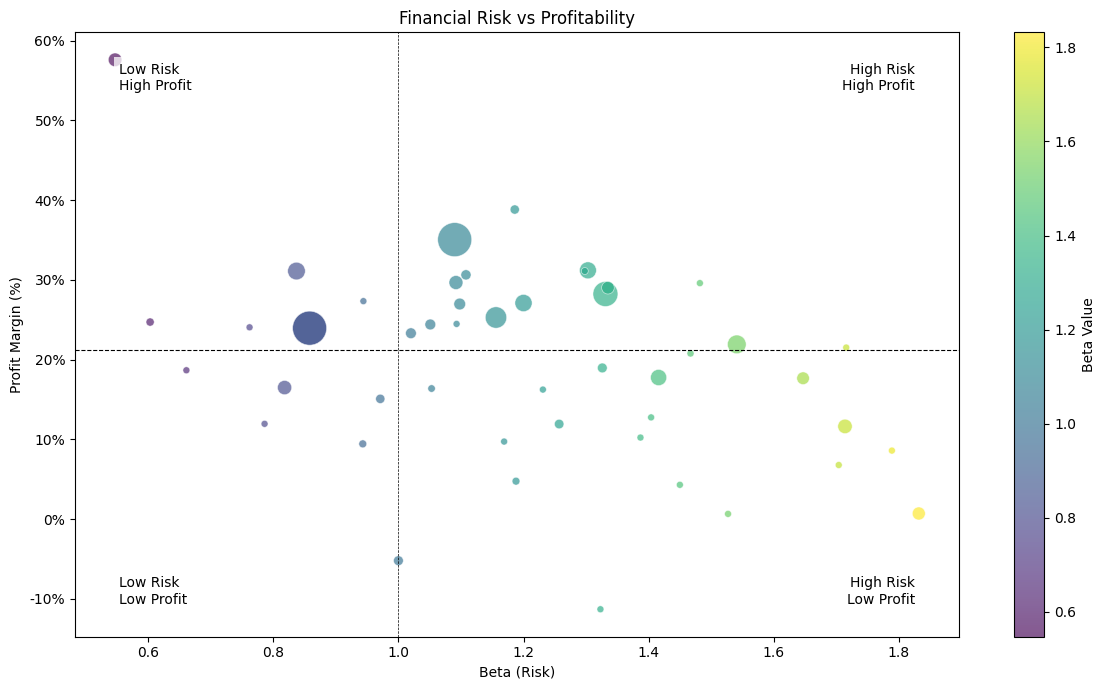

In [ ]:
# ============================================================
# 6 — Bubble Chart
# ============================================================

# In this bubble chart, we analyze the relationship between business risk (on the x-axis) and profit margin (on the y-axis). 
# The main goal is to determine if a company is generating enough profit to justify its risk exposure. 
# We expect high-risk businesses to yield higher profit margins compared to low-risk ones. 
# After all, taking on greater risk only makes sense from a business perspective if it leads to a higher financial return.

# claning data 
scatter_df = df_cleaned.dropna(subset=['beta', 'profit_margin_pct', 'market_cap_b']).copy()
scatter_df = scatter_df[(scatter_df['beta'].between(0, 3)) & (scatter_df['profit_margin_pct'].between(-50, 80))]

# configurating the graph
fig, ax = plt.subplots(figsize=(12, 7))
sizes = (np.exp(scatter_df['market_cap_b'])).clip(lower=25, upper=600)

points = ax.scatter(
    scatter_df['beta'], 
    scatter_df['profit_margin_pct'], 
    s=sizes, 
    c=scatter_df['beta'],
    cmap="viridis",
    alpha=0.65, 
    edgecolors='white', 
    linewidth=0.5
)

ax.axvline(x=1.0, color='black', linewidth=0.5, linestyle='--')
ax.axhline(y=scatter_df['profit_margin_pct'].median(), color='black', linewidth=0.8, linestyle='--')

# put the labels
bbox_props = dict(facecolor="white", alpha=0.75, edgecolor="none")
ax.text(0.05, 0.95, "Low Risk\nHigh Profit", transform=ax.transAxes, fontsize=10, ha="left", va="top", bbox=bbox_props)
ax.text(0.95, 0.95, "High Risk\nHigh Profit", transform=ax.transAxes, fontsize=10, ha="right", va="top", bbox=bbox_props)
ax.text(0.05, 0.05, "Low Risk\nLow Profit", transform=ax.transAxes, fontsize=10, ha="left", va="bottom", bbox=bbox_props)
ax.text(0.95, 0.05, "High Risk\nLow Profit", transform=ax.transAxes, fontsize=10, ha="right", va="bottom", bbox=bbox_props)
ax.set_title('Financial Risk vs Profitability')
ax.set_xlabel('Beta (Risk)')
ax.set_ylabel('Profit Margin (%)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0f}%'))
plt.colorbar(points, ax=ax, label='Beta Value')

plt.tight_layout()
plt.show()

[*********************100%***********************]  10 of 10 completed


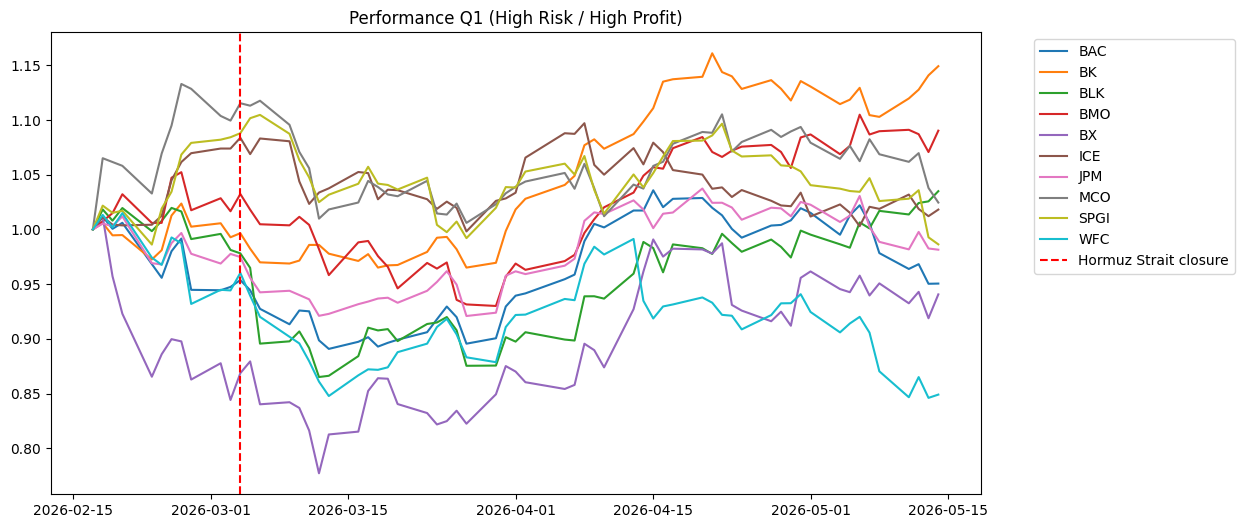

In [ ]:
# ============================================================
# 7 — Zoom into One Quadrant
# ============================================================

# Justification of Choice (Q1)
# I selected the 1st Quadrant (High risk & High profit) because it includes companies that combine high operational efficiency with high sensitivity to market trends. 
# In the context of a geopolitical crisis, these stocks are expected to be the most volatile, even though they maintain solid fundamentals.
# Moreover we are gonna show how the market trend of those companies has been affected by the Strait of Hormuz closure, 
# this gives us the opportunity to strudy how those are influeced by geopolitical crysis.

y_median = df_cleaned['profit_margin_pct'].median()

q1_df = df_cleaned[
    (df_cleaned['beta'] > 1.0) & 
    (df_cleaned['profit_margin_pct'] > y_median)
].copy()

top_10_q1 = q1_df.nlargest(10, 'market_cap_b')

data_q1 = yf.download(top_10_q1['symbol'].tolist(), period="3mo")['Close']
normalized_q1 = data_q1 / data_q1.iloc[0]

plt.figure(figsize=(12, 6))
for ticker in normalized_q1.columns:
    plt.plot(normalized_q1.index, normalized_q1[ticker], label=ticker)
plt.axvline(pd.to_datetime('2026-03-04'), color='red', linestyle='--', label='Hormuz Strait closure')
plt.title("Performance Q1 (High Risk / High Profit)")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

### Event Analysis: Hormuz Strait Closure Impact

As shown in the chart, the selected quadrant experienced a sharp decline immediately following the closure of the Hormuz Strait, reflecting the market's reaction to disruptions in global oil exports. 

Following this initial shock and a period of high instability, the markets entered a phase of stabilization and gradual recovery. However, the long-term impact on the analyzed financial companies was mixed. Rather than remaining unchanged, the sector displayed significant divergence: while some companies demonstrated strong resilience and eventually surpassed their pre-crisis levels, others struggled to recover, highlighting the different degrees of vulnerability within this specific industry segment.

[*********************100%***********************]  5 of 5 completed


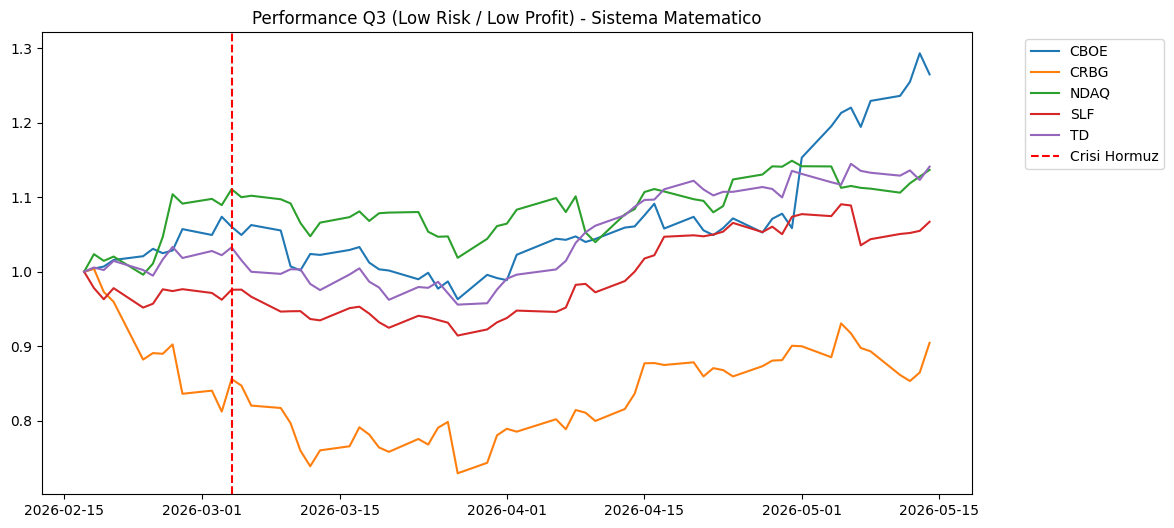

In [ ]:
# ============================================================
# 8 — Compare with an Excluded Quadrant
# ============================================================

# Justification of Choice (Q3 - Low Risk vs. Low Profit)
# For a direct comparison, I selected the opposite quadrant, which features companies with low risk and low profit margins. 
# The goal is to highlight the differences between the two groups and analyze how the economic stability of these more conservative businesses was impacted by the crisis.

q3_df = df_cleaned[
    (df_cleaned['beta'] < 1.0) & 
    (df_cleaned['profit_margin_pct'] < y_median)
].copy()

top_10_q3 = q3_df.nlargest(10, 'market_cap_b')

data_q3 = yf.download(top_10_q3['symbol'].tolist(), period="3mo")['Close']
normalized_q3 = data_q3 / data_q3.iloc[0]

plt.figure(figsize=(12, 6))
for ticker in normalized_q3.columns:
    plt.plot(normalized_q3.index, normalized_q3[ticker], label=ticker)
plt.axvline(pd.to_datetime('2026-03-04'), color='red', linestyle='--', label='Crisi Hormuz')
plt.title("Performance Q3 (Low Risk / Low Profit) - Sistema Matematico")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()


### Final Comparison and Reflection

The 1st Quadrant (High Risk/High Profit) reacted to the Hormuz crisis with much wider swings. 
The stocks showed rapid fluctuations both during the drop and the rebound attempts, confirming the impact of a high Beta.

The 3rd Quadrant (Low Risk/Low Profit) proved to be much "flatter." 
Despite having low margins that theoretically make them vulnerable to energy costs, their low correlation with the overall market (Beta < 1) prevented the panic crashes seen in Q1.

The Beta/Profit combination explains this behavior well. 
Q1 follows market sentiment (geopolitical shock = quick sell-off), while Q3 follows a more conservative and less speculative logic, making it less affected by the tensions in the Strait.

Q1 shows clearer signs of recovery by May 2026, as investors quickly return to highly profitable stocks once the tension eases. 
Q3, on the other hand, remains more stagnant, confirming its modest return profile.

### Summary of Analysis: Financial Services Sector

**Sector Structure: Size, Profitability, and Risk**
The Financial Services sector presents a highly skewed market capitalization distribution. While the median company size remains relatively modest—typically ranging between $2 billion and $4 billion—the overall market is heavily dominated by a select few "mega-cap" giants. Across the sector, there is a broad spectrum of profitability and risk. Performance ranges from highly volatile, high-margin entities to stable, defensive companies that provide steady but lower profit margins.

**Industry Selection**
Then we explored four specific industries. First, "Banks - Diversified", chosen for its robust market scale, consistent profitability, and well-balanced risk profile. Second, "Asset Management" was selected due to its strong revenue stability and margins, offering excellent potential for long-term growth. Third, "Financial Data & Stock Exchanges" included because it combines exceptional operational efficiency with a moderate, modern risk profile. Last one," Insurance - Diversified " chosen as a  defensive asset, boasting the lowest and most stable Beta among its peers. Other industries, were  excluded due to their excessively high volatility or unpredictable margins that fell outside our target risk thresholds.

**Bubble Chart Insights**
By analyzing the bubble chart we evaluated whether companies generated sufficient profit to justify their systemic risk exposure. The chart distinctly categorized the universe into four quadrants, validating that while many companies align with the traditional expectation of "higher risk equals higher reward," notable dispersion remains. This visual mapping allowed us to easily isolate the extremes for direct comparison: Quadrant 1 (High Risk/High Profit) and Quadrant 3 (Low Risk/Low Profit).

**Recent Performance and Geopolitical Context**
Over the last three months, the market was heavily disrupted by a major geopolitical shock: the closure of the Strait of Hormuz on March 4, 2026. Tracking the performance of the Q1 and Q3 groups revealed starkly different reactions to this event. 

As anticipated, Q1 (High Risk/High Profit) companies experienced significant volatility. They suffered a sharp, immediate sell-off following the Strait's closure, accurately reflecting the panicked market sentiment regarding global energy disruptions. However, by May 2026, these high-Beta stocks demonstrated strong signs of recovery as investors quickly returned to their underlying high profitability once the initial shock subsided. 

Conversely, Q3 (Low Risk/Low Profit) companies exhibited a much flatter trajectory. Their low correlation with the broader market (Beta < 1) successfully insulated them from the initial panic crashes. This difference perfectly aligned with our expectations given the geopolitical context: the high-Beta group amplified market shocks but rebounded strongly due to solid operational fundamentals, while the low-Beta group offered conservative stability, avoiding the steep crash but remaining stagnant during the recovery phase.